# The Best Neighborhood in Pittsburgh
## Final Ranking

In this notebook, we combine three sub-metrics developed independently by our team members to produce a single, group-level ranking of Pittsburgh neighborhoods. Each sub-metric focuses on a different aspect of "bestness":

- **Ruoyu** — Safety: crime incidents per 100k residents (lower is better)
- **Ruizhi** — Community Activity: normalized community center attendance (higher is better)
- **Zibo** — Neighborhood Vibrancy: parking transaction activity score (higher is better)

Each group member's personal notebook is included in their respective files.

Our goal is to normalize these scores to a common **0~100 scale**, decide on a weighting scheme, and then compute a combined score that allows us to identify the single "best" neighborhood in Pittsburgh according to our data-driven metric.

## The Data

Each metric is reconstructed from its original dataset in this notebook. The individual data cleaning and feature engineering steps for each metric are documented in our three personal notebooks. Here we focus exclusively on **cleaning, normalizing, combining** the three scores and producing a final ranking.

> **Note on coverage:** The Safety dataset covers 81 Pittsburgh neighborhoods; the Community Center dataset covers 16 neighborhoods (limited by facility locations); the Parking dataset covers 42 neighborhoods (mapped from 60 parking zones). The three-way intersection yields **7 neighborhoods**, which form the basis of our final combined ranking.

## Setup

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Edit DATA_DIR if CSV files are not in the same folder as this notebook
DATA_DIR = '.'

def data(filename):
    return os.path.join(DATA_DIR, filename)

required = ['blotter-data.csv', 'total-population.csv', 'Community_Center_Daily_Attendance.csv']
for f in required:
    status = 'found' if os.path.exists(data(f)) else 'NOT FOUND'
    print(f"{status}: {f}")

found: blotter-data.csv
found: total-population.csv
found: Community_Center_Daily_Attendance.csv


## Individual Metric Results

Before combining the metrics, let's first review each team member's individual findings.

### Safety (Ruoyu)

           neighborhood         score
1       Mt. Oliver Boro   2971.462195
2             Troy Hill  11038.107753
3    Central North Side  27178.423237
4        Swisshelm Park  32936.802974
5   Squirrel Hill North  36062.103035
6         New Homestead  36279.547790
7       Stanton Heights  39592.522579
8           Summer Hill  43912.678421
9            Banksville  46526.697771
10             Westwood  46649.703138


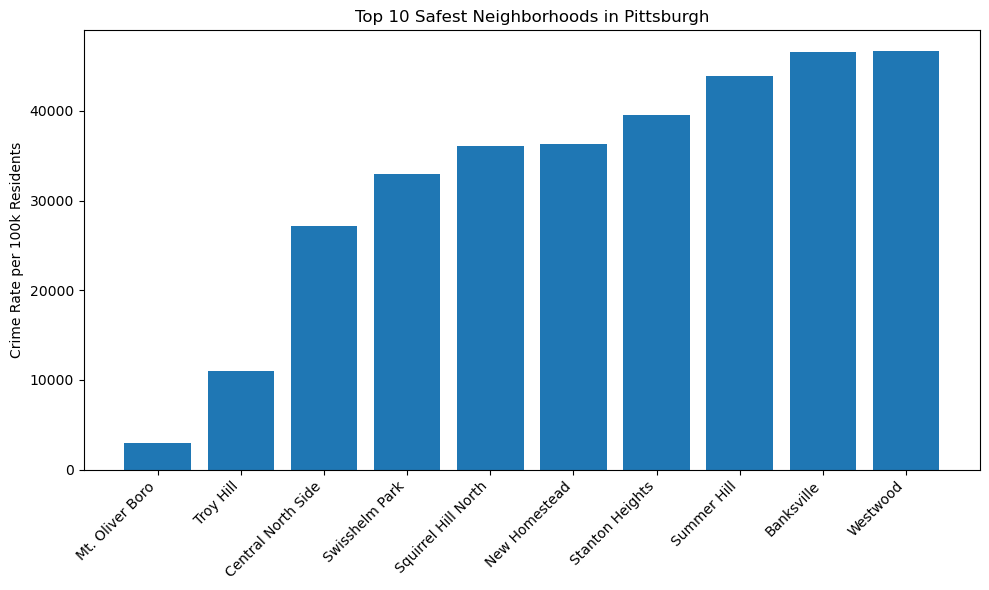

In [14]:
safety_raw = pd.read_csv(data('blotter-data.csv'))
population_data = pd.read_csv(data('total-population.csv'),
                               usecols=['Neighborhood', 'Estimate; Total'])
population_data.columns = ['neighborhood', 'population']

crime_counts = safety_raw.groupby('INCIDENTNEIGHBORHOOD').size().reset_index()
crime_counts.columns = ['neighborhood', 'crime_count']
crime_counts['neighborhood'] = crime_counts['neighborhood'].replace({
    'Central Northside': 'Central North Side',
    'Troy Hill-Herrs Island': 'Troy Hill',
})
crime_counts = crime_counts[~crime_counts['neighborhood'].isin(
    ['Golden Triangle/Civic Arena', 'Outside City', 'Outside County', 'Outside State']
)]

safety_merged = pd.merge(crime_counts, population_data, on='neighborhood', how='inner')
safety_merged = safety_merged[safety_merged['population'] >= 500]
safety_merged['score'] = (safety_merged['crime_count'] / safety_merged['population']) * 100000

safety_df = safety_merged[['neighborhood', 'score']].copy()

safety_sorted = safety_df.sort_values('score').reset_index(drop=True)
safety_sorted.index = safety_sorted.index + 1
print(safety_sorted.head(10).to_string())

top10_safety = safety_sorted.head(10)
plt.figure(figsize=(10, 6))
plt.bar(top10_safety['neighborhood'], top10_safety['score'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Crime Rate per 100k Residents')
plt.title('Top 10 Safest Neighborhoods in Pittsburgh')
plt.tight_layout()
plt.show()

### Community Activity (Ruizhi)

                neighborhood   score
1                  Brookline  379531
2                Polish Hill  275371
3                    Carrick  255371
4              Hill District  178345
5                Beltzhoover  131886
6                 Greenfield  107248
7           South Side Flats  106977
8         Central North Side   78635
9   Lincoln-Lemington-Belmar   74965
10                 Arlington   74899


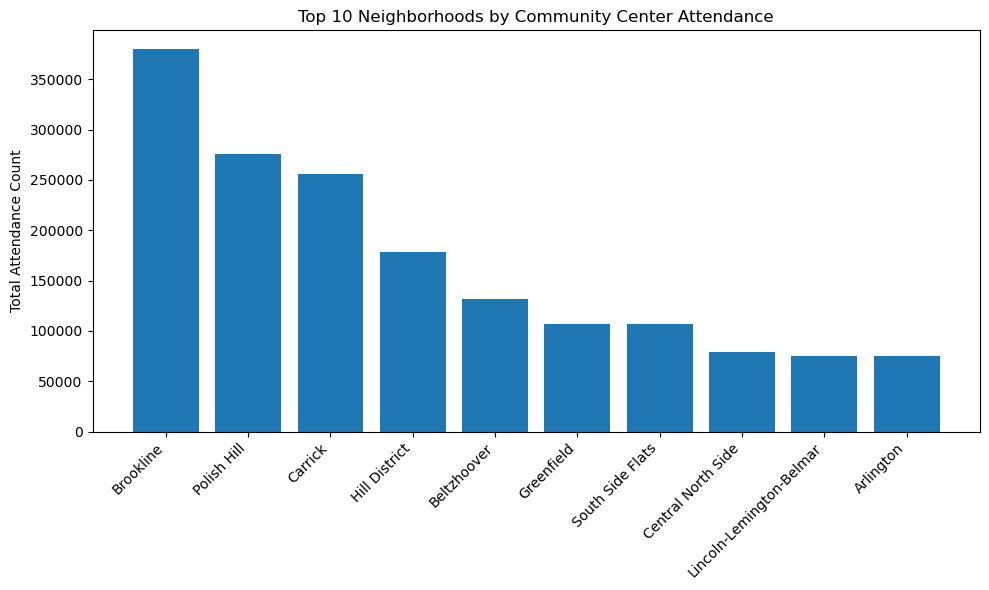

In [15]:
cc_raw = pd.read_csv(data('Community_Center_Daily_Attendance.csv'))

center_to_neighborhood = {
    "Brookline Community Center": "Brookline",
    "West Penn Community Center": "Polish Hill",
    "Phillips Community Center": "Carrick",
    "Ammon Community Center": "Hill District",
    "Warrington Community Center": "Beltzhoover",
    "Magee Community Center": "Greenfield",
    "Ormsby Community Center": "South Side Flats",
    "Jefferson Community Center": "Central North Side",
    "Arlington Community Center": "Arlington",
    "Paulson Community Center": "Lincoln-Lemington-Belmar",

    "Phillips Park Field": "Carrick",
    "Gladstone Field": "Hazelwood",
    "Ormsby Field (Playground)": "South Side Flats",
    "Paulson Field": "Lincoln-Lemington-Belmar",
    "Mellon Tennis Center": "Shadyside",
    "West Penn Fields": "Polish Hill",
    "West Penn Pool": "Polish Hill",
    "Frazier Park": "South Oakland",
    "Ammon Pool": "Hill District",
    "Jefferson Recreation Center": "Central North Side",
    "Schenley Ice Rink": "Squirrel Hill South",
    "Warrington Field": "Beltzhoover",
    "Highland Pool": "Highland Park",
    "Arlington Field": "South Side Slopes",
    "Burgwin Field": "Hazelwood",
    "Frick Environmental Center": "Squirrel Hill South",
    "Moore Pool": "Brookline",
    "Ammon Park": "Hill District"
}
cc_raw['neighborhood'] = cc_raw['center_name'].map(center_to_neighborhood)
cc_grouped = cc_raw.groupby('neighborhood')['attendance_count'].sum().reset_index()
cc_grouped.columns = ['neighborhood', 'score']

community_df = cc_grouped.copy()

community_sorted = community_df.sort_values('score', ascending=False).reset_index(drop=True)
community_sorted.index = community_sorted.index + 1
print(community_sorted.head(10).to_string())

top10_cc = community_sorted.head(10)
plt.figure(figsize=(10, 6))
plt.bar(top10_cc['neighborhood'], top10_cc['score'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Total Attendance Count')
plt.title('Top 10 Neighborhoods by Community Center Attendance')
plt.tight_layout()
plt.show()


### Neighborhood Vibrancy — Parking Activity (Zibo)

Zibo's metric uses aggregated parking transactions as a proxy for neighborhood vibrancy. Because the parking dataset uses zone-level boundaries (not neighborhood boundaries), scores are mapped manually to the 9 most representative neighborhoods.

Total neighborhoods in parking data: 42
           neighborhood     score
1     South Side Slopes  1.000000
2      South Side Flats  1.000000
3        Strip District  0.670441
4   Squirrel Hill South  0.659113
5   Squirrel Hill North  0.659113
6            Bloomfield  0.517475
7      Allegheny Center  0.509227
8        Allegheny West  0.509227
9     Central Northside  0.509227
10          North Shore  0.509227
11       East Allegheny  0.509227
12            Shadyside  0.503678
13        South Oakland  0.501510
14        North Oakland  0.501510
15         West Oakland  0.501510


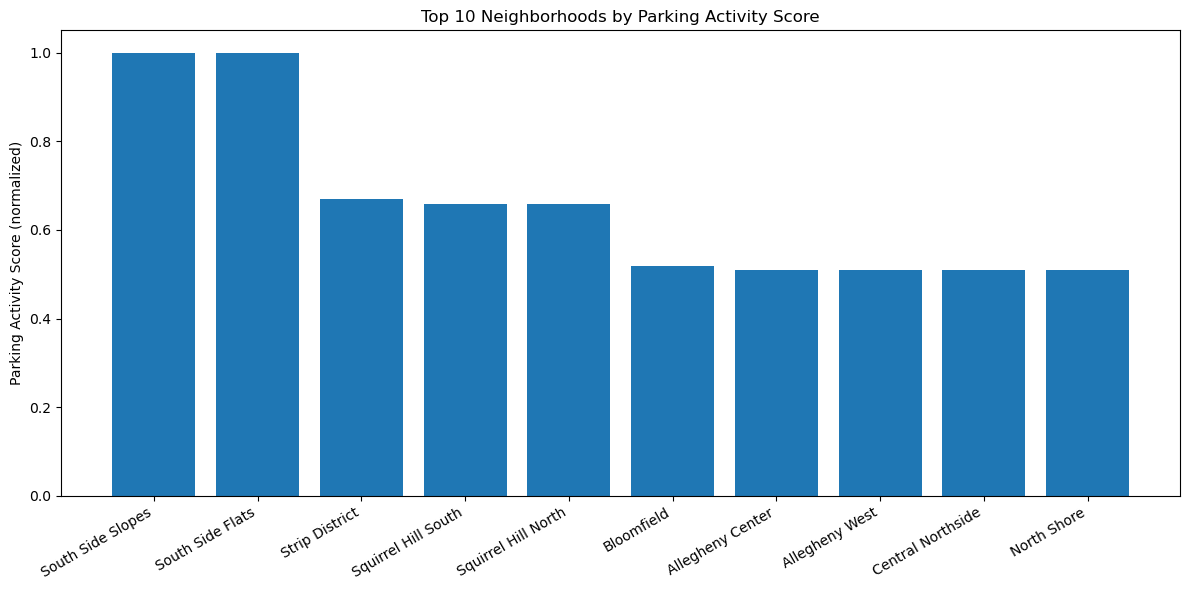

In [16]:
# Zone-level activity scores from Zibo's parking analysis
zone_data = {
    '415 - SS & SSW': 1.000000, '404 - Strip Disctrict': 0.670441,
    '413 - Squirrel Hill': 0.659113, '406 - Bloomfield (On-street)': 0.517475,
    '421 - NorthSide': 0.509227, '411 - Shadyside': 0.503678,
    '410 - Oakland 4': 0.501510, '402 - Downtown 2': 0.468864,
    '401 - Downtown 1': 0.460785, '412 - East Liberty': 0.432678,
    '409 - Oakland 3': 0.423294, '408 - Oakland 2': 0.407196,
    '407 - Oakland 1': 0.352999, '403 - Uptown': 0.337394,
    '328 - Ivy Bellefonte Lot': 0.226479, '419 - Brookline': 0.190570,
    '405 - Lawrenceville': 0.168158, '422 - Northshore': 0.161214,
    '322 - Forbes Shady Lot': 0.145953, '324 - Forbes Murray Lot': 0.144276,
    '325 - JCC/Forbes Lot': 0.120388, '344 - 18th & Carson Lot': 0.075529,
    '321 - Beacon Bartlett Lot': 0.068063, '335 - Friendship Cedarville Lot': 0.067023,
    '341 - 18th & Sidney Lot': 0.061711, '357 - Shiloh Street Lot': 0.060515,
    '342 - East Carson Lot': 0.055105, '304 - Tamello Beatty Lot': 0.052848,
    '420 - Mt. Washington': 0.049022, '302 - Sheridan Kirkwood Lot': 0.040488,
    '343 - 19th & Carson Lot': 0.039874, '338 - 42nd & Butler Lot': 0.037578,
    '345 - 20th & Sidney Lot': 0.032383, '371 - East Ohio Street Lot': 0.027606,
    '323 - Douglas Phillips Lot': 0.024338, '334 - Taylor Street Lot': 0.022168,
    '307 - Eva Beatty Lot': 0.019019, '416 - Carrick': 0.017225,
    '414 - Mellon Park': 0.014784, '418 - Beechview': 0.013521,
    '329 - Centre Craig': 0.013486, '351 - Brownsville & Sandkey Lot': 0.011348,
    '424 - Technology Drive': 0.010373, '314 - Penn Circle NW Lot': 0.008040,
    '425 - Bakery Sq': 0.007356, '301 - Sheridan Harvard Lot': 0.007225,
    '337 - 52nd & Butler Lot': 0.007071, '355 - Asteroid Warrington Lot': 0.006870,
    '311 - Ansley Beatty Lot': 0.005487, '423 - West End': 0.005426,
    '417 - Allentown': 0.004635, '369 - Main/Alexander Lot': 0.003850,
    '308 - Harvard Beatty Lot': 0.003137, '375 - Oberservatory Hill Lot': 0.003050,
    '426 - Hill District': 0.002980, '363 - Beechview Lot': 0.001865,
    '427 - Knoxville': 0.001085, '354 - Walter/Warrington Lot': 0.001041,
    '361 - Brookline Lot': 0.001012, '331 - Homewood Zenith Lot': 0.000808,
}

# Map each parking zone to one or more neighborhoods
zone_to_neighborhood = {
    '415 - SS & SSW': 'South Side Flats / South Side Slopes',
    '404 - Strip Disctrict': 'Strip District',
    '413 - Squirrel Hill': 'Squirrel Hill North / Squirrel Hill South',
    '406 - Bloomfield (On-street)': 'Bloomfield',
    '421 - NorthSide': 'North Shore / Allegheny Center / Central Northside / East Allegheny / Allegheny West',
    '411 - Shadyside': 'Shadyside',
    '410 - Oakland 4': 'North Oakland / Central Oakland / South Oakland / West Oakland',
    '402 - Downtown 2': 'Central Business District',
    '401 - Downtown 1': 'Central Business District',
    '412 - East Liberty': 'East Liberty',
    '409 - Oakland 3': 'North Oakland / Central Oakland / South Oakland / West Oakland',
    '408 - Oakland 2': 'North Oakland / Central Oakland / South Oakland / West Oakland',
    '407 - Oakland 1': 'North Oakland / Central Oakland / South Oakland / West Oakland',
    '403 - Uptown': 'Uptown',
    '328 - Ivy Bellefonte Lot': 'Shadyside',
    '419 - Brookline': 'Brookline',
    '405 - Lawrenceville': 'Lower Lawrenceville / Central Lawrenceville / Upper Lawrenceville',
    '422 - Northshore': 'North Shore',
    '322 - Forbes Shady Lot': 'Squirrel Hill North / Squirrel Hill South',
    '324 - Forbes Murray Lot': 'Squirrel Hill North / Squirrel Hill South',
    '325 - JCC/Forbes Lot': 'Squirrel Hill North / Squirrel Hill South',
    '344 - 18th & Carson Lot': 'South Side Flats',
    '321 - Beacon Bartlett Lot': 'Squirrel Hill North / Squirrel Hill South',
    '335 - Friendship Cedarville Lot': 'Friendship',
    '341 - 18th & Sidney Lot': 'South Side Flats',
    '357 - Shiloh Street Lot': 'Mount Washington',
    '342 - East Carson Lot': 'South Side Flats',
    '304 - Tamello Beatty Lot': 'East Liberty',
    '420 - Mt. Washington': 'Mount Washington',
    '302 - Sheridan Kirkwood Lot': 'East Liberty',
    '343 - 19th & Carson Lot': 'South Side Flats',
    '338 - 42nd & Butler Lot': 'Central Lawrenceville',
    '345 - 20th & Sidney Lot': 'South Side Flats',
    '371 - East Ohio Street Lot': 'East Allegheny',
    '323 - Douglas Phillips Lot': 'Squirrel Hill North / Squirrel Hill South',
    '334 - Taylor Street Lot': 'Bloomfield',
    '307 - Eva Beatty Lot': 'East Liberty',
    '416 - Carrick': 'Carrick',
    '414 - Mellon Park': 'Point Breeze / Shadyside / Squirrel Hill North',
    '418 - Beechview': 'Beechview',
    '329 - Centre Craig': 'North Oakland',
    '351 - Brownsville & Sandkey Lot': 'Carrick',
    '424 - Technology Drive': 'South Oakland',
    '314 - Penn Circle NW Lot': 'East Liberty',
    '425 - Bakery Sq': 'Larimer / Shadyside',
    '301 - Sheridan Harvard Lot': 'East Liberty',
    '337 - 52nd & Butler Lot': 'Upper Lawrenceville',
    '355 - Asteroid Warrington Lot': 'Allentown',
    '311 - Ansley Beatty Lot': 'East Liberty',
    '423 - West End': 'West End',
    '417 - Allentown': 'Allentown',
    '369 - Main/Alexander Lot': 'Bloomfield',
    '308 - Harvard Beatty Lot': 'East Liberty',
    '375 - Oberservatory Hill Lot': 'Perry North / Observatory Hill',
    '426 - Hill District': 'Bedford Dwellings / Middle Hill / Crawford-Roberts / Terrace Village / Upper Hill',
    '363 - Beechview Lot': 'Beechview',
    '427 - Knoxville': 'Knoxville',
    '354 - Walter/Warrington Lot': 'Allentown',
    '361 - Brookline Lot': 'Brookline',
    '331 - Homewood Zenith Lot': 'Homewood North / Homewood South / Homewood West',
}

# Expand zone -> neighborhood rows, take max score per neighborhood
rows = []
for zone, score in zone_data.items():
    for n in zone_to_neighborhood.get(zone, '').split(' / '):
        rows.append({'neighborhood': n.strip(), 'score': score})

parking_df = (
    pd.DataFrame(rows)
    .groupby('neighborhood')['score']
    .max()
    .reset_index()
    .sort_values('score', ascending=False)
    .reset_index(drop=True)
)

parking_sorted = parking_df.copy()
parking_sorted.index = parking_sorted.index + 1
print(f"Total neighborhoods in parking data: {len(parking_df)}")  # should be 42
print(parking_sorted.head(15).to_string())

top10_parking = parking_df.head(10)
plt.figure(figsize=(12, 6))
plt.bar(top10_parking['neighborhood'], top10_parking['score'])
plt.xticks(rotation=30, ha='right')
plt.ylabel('Parking Activity Score (normalized)')
plt.title('Top 10 Neighborhoods by Parking Activity Score')
plt.tight_layout()
plt.show()

## Combined Metric Process

Now that we've reviewed each individual metric, we'll combine them into a single comprehensive ranking.

### 1. Clean Data

Before we can combine the three metrics, we need to ensure the data is clean and consistent.
Here we keep only neighborhoods that appear in **all three datasets** to ensure fair comparison,
and remove any rows with missing data.

In [17]:
# Rename score columns
safety_df2    = safety_df.rename(columns={'score': 'safety_score'})
community_df2 = community_df.rename(columns={'score': 'community_score'})
parking_df2   = parking_df.rename(columns={'score': 'parking_score'})

# Keep only neighborhoods present in all three datasets
merged = safety_df2.merge(community_df2, on='neighborhood', how='inner')
merged = merged.merge(parking_df2, on='neighborhood', how='inner')
merged = merged.dropna()

print(f"Neighborhoods appearing in all 3 datasets: {len(merged)}")
print(merged[['neighborhood', 'safety_score', 'community_score', 'parking_score']].to_string(index=False))

Neighborhoods appearing in all 3 datasets: 7
       neighborhood  safety_score  community_score  parking_score
          Brookline  59209.726444           379531       0.190570
            Carrick 117832.444181           255371       0.017225
          Shadyside  64688.099100              130       0.503678
      South Oakland  83601.506333              104       0.501510
   South Side Flats 303528.289892           106977       1.000000
  South Side Slopes  94326.860135                9       1.000000
Squirrel Hill South  48678.469019               55       0.659113


### Handle Outliers in Safety Score

Some neighborhoods have extremely high crime rates that could distort our normalization process.
We cap the safety scores at the **96th percentile** to prevent a few extreme outliers from
compressing the scores of the majority of neighborhoods into a narrow range,
while still preserving relative differences.

In [18]:
percentile_96 = merged['safety_score'].quantile(0.96)
print(f"96th percentile of safety score: {percentile_96:.2f}")
print(f"Neighborhoods above 96th percentile: {(merged['safety_score'] > percentile_96).sum()}")

merged['safety_score_capped'] = merged['safety_score'].clip(upper=percentile_96)

96th percentile of safety score: 258961.29
Neighborhoods above 96th percentile: 1


### 2. Normalize Scores to [0, 100]

We normalize all scores to a common scale of 0 to 100. This ensures that each metric
contributes proportionally to the final score, regardless of their original units or ranges.

In [19]:
def normalize(series):
    return ((series - series.min()) / (series.max() - series.min())) * 100

merged['safety_norm']    = normalize(merged['safety_score_capped'])  # 0=safest, 100=most dangerous
merged['community_norm'] = normalize(merged['community_score'])       # 0=least active, 100=most active
merged['parking_norm']   = merged['parking_score'] * 100             # already in [0,1], scale to [0,100]

print(merged[['neighborhood', 'safety_norm', 'community_norm', 'parking_norm']].to_string(index=False))

       neighborhood  safety_norm  community_norm  parking_norm
          Brookline     5.008140      100.000000       19.0570
            Carrick    32.886175       67.285164        1.7225
          Shadyside     7.613380        0.031882       50.3678
      South Oakland    16.607651        0.025031       50.1510
   South Side Flats   100.000000       28.184927      100.0000
  South Side Slopes    21.708094        0.000000      100.0000
Squirrel Hill South     0.000000        0.012121       65.9113


### 3.1 Calculate Final Score

Next we can obtain the final score with our combined metric:

**Weights:**
- Community Activity: **1**
- Neighborhood Vibrancy (Parking): **1**
- Safety: **2**

**Formula:**

$$\text{Final Score} = \text{Community} + \text{Parking} - 2 \times \text{Safety}$$

*Note: Higher Safety Score means higher crime rate, so we subtract it.*

In [20]:
# Calculate final score: Community(+1) + Parking(+1) - Safety(×2)
merged['final_score'] = (
    merged['community_norm']
    + merged['parking_norm']
    - 2 * merged['safety_norm']
)

result = merged.sort_values('final_score', ascending=False).reset_index(drop=True)
result['rank'] = range(1, len(result) + 1)

print("BEST NEIGHBORHOODS IN PITTSBURGH (all 3 datasets)")
print(result[['rank', 'neighborhood', 'final_score',
              'safety_norm', 'community_norm', 'parking_norm']].to_string(index=False))

BEST NEIGHBORHOODS IN PITTSBURGH (all 3 datasets)
 rank        neighborhood  final_score  safety_norm  community_norm  parking_norm
    1           Brookline   109.040720     5.008140      100.000000       19.0570
    2 Squirrel Hill South    65.923421     0.000000        0.012121       65.9113
    3   South Side Slopes    56.583813    21.708094        0.000000      100.0000
    4           Shadyside    35.172922     7.613380        0.031882       50.3678
    5       South Oakland    16.960729    16.607651        0.025031       50.1510
    6             Carrick     3.235314    32.886175       67.285164        1.7225
    7    South Side Flats   -71.815073   100.000000       28.184927      100.0000


### 3.2 Visualization

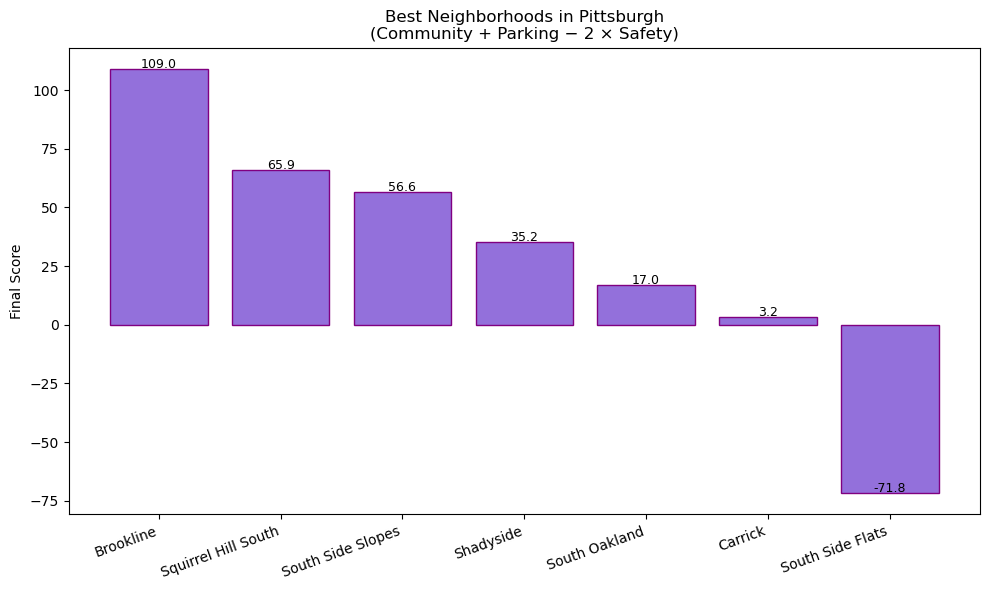

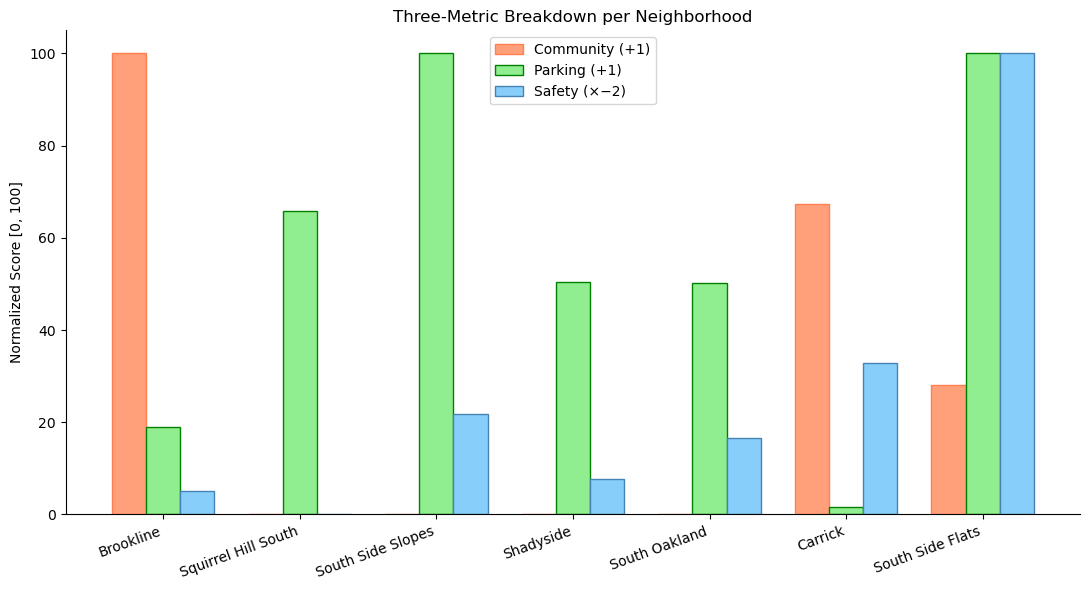

In [21]:
# Visualization 1: Final combined score
plt.figure(figsize=(10, 6))
plt.bar(result['neighborhood'], result['final_score'], color='mediumpurple', edgecolor='purple')
plt.xticks(rotation=20, ha='right')
plt.ylabel('Final Score')
plt.title('Best Neighborhoods in Pittsburgh\n(Community + Parking − 2 × Safety)')
for i, row in result.iterrows():
    plt.text(i, row['final_score'] + 0.5, f"{row['final_score']:.1f}", ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('combined_final.png', dpi=150, bbox_inches='tight')
plt.show()

# Visualization 2: Per-metric breakdown
x = range(len(result))
bar_w = 0.25
fig, ax = plt.subplots(figsize=(11, 6))
ax.bar([i - bar_w for i in x], result['community_norm'], bar_w,
       label='Community (+1)', color='LightSalmon', edgecolor='coral')
ax.bar(x,                      result['parking_norm'],   bar_w,
       label='Parking (+1)',   color='LightGreen',  edgecolor='green')
ax.bar([i + bar_w for i in x], result['safety_norm'],    bar_w,
       label='Safety (×−2)',   color='LightSkyBlue', edgecolor='steelblue')
ax.set_xticks(list(x))
ax.set_xticklabels(result['neighborhood'], rotation=20, ha='right')
ax.set_ylabel('Normalized Score [0, 100]')
ax.set_title('Three-Metric Breakdown per Neighborhood')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('combined_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.1 Conclusion

Based on our combined metric (Community + Parking − 2 × Safety) applied to the **7 neighborhoods
that appear in all three datasets**, the best neighborhood in Pittsburgh is **Brookline**.

From a data perspective, Brookline performs consistently well across all three dimensions:
- It has the **highest community center attendance** among the 7 neighborhoods (normalized score = 100).
- Its **crime rate is very low**, giving it a strong safety advantage.
- It has **moderate parking activity**, indicating a lively but not overcrowded residential area.

## 4.2 Reflection

**Ruoyu:** My favorite neighborhood is Squirrel Hill South, where I currently live. Life here is very
convenient — there are large supermarkets like Giant Eagle, Asian markets like Panda Supermarket,
and many international restaurants. Beyond food and shopping, Squirrel Hill South is also very safe;
I often come home late at night and always feel secure. This aligns with our data: Squirrel Hill South
ranks well on both safety and parking vibrancy in our final ranking.

**Ruizhi:** Based on my analysis, Brookline is identified as the best neighborhood under my community activity metric because it has the highest community center attendance. This suggests that Brookline has very active public community spaces and strong use of shared resources. However, my personal preference may not fully match this result. Because I care more about traffic convenience. From that perspective, Brookline may not be ideal for me. Therefore, while Brookline is the best neighborhood according to my attendance metric, my personal favorite neighborhood would depend more on transportation convenience than attendance numbers alone.

**Zibo:** South Side Flats ranks highest in parking activity among our 8 neighborhoods, reflecting
its density of restaurants, bars, and entertainment along East Carson Street. Personally, however,
I would prefer a neighborhood that balances vibrancy with safety and residential comfort.